## # STUDENT PERFORMANCE ANALYSIS

THIS PROJECT ANALYZES STUDENT PERFORMANCE USING A DATASET TO UNDERSTAND HOW FACTORS LIKE STUDY TIME AND ABSENCES AFFECT FINAL GRADES. BASIC DATA ANALYSIS, VISUALIZATION, AND A SIMPLE MACHINE LEARNING MODEL ARE USED TO DERIVE INSIGHTS.

# DATA PREPARATION

In [11]:
import pandas as pd
df = pd.read_csv("/Users/tashvisumit/Downloads/archive (6)/student 2/student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [28]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

##It was observed that there are no missing values in any column, indicating that the dataset is complete and clean.

#  Analysis

In [31]:
df.groupby('studytime')['G3'].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

###The analysis shows that students with higher study time tend to achieve better marks. However, the relationship is not perfectly linear, as performance slightly decreases at the highest study level. This indicates that other factors may also influence student performance.

# Visualizations

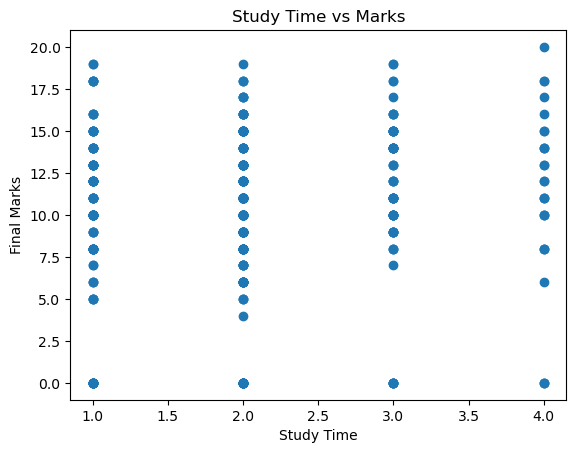

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df['studytime'], df['G3'])
plt.xlabel("Study Time")
plt.ylabel("Final Marks")
plt.title("Study Time vs Marks")
plt.show()

###The scatter plot illustrates the relationship between study time and final marks of students. It is observed that students with higher study time generally achieve better marks. However, the data points are widely distributed, indicating that study time alone does not completely determine student performance. Other factors such as attendance, health, and personal habits may also influence the results.

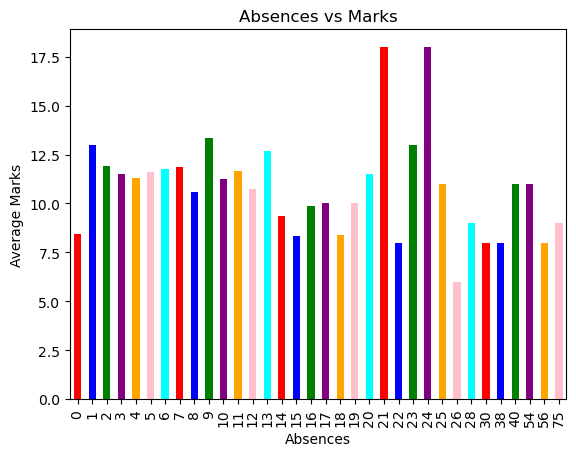

In [47]:
df.groupby('absences')['G3'].mean().plot(
    kind='bar',
    color=['red','blue','green','purple','orange','pink','cyan']
)

plt.xlabel("Absences")
plt.ylabel("Average Marks")
plt.title("Absences vs Marks")
plt.show()

###The chart shows that students with higher absences tend to have lower marks.

# CONCLUSION

###The dataset was analyzed to understand the factors affecting student performance. It was observed that study time has a positive impact on marks, as students who study more tend to perform better. On the other hand, absences have a negative effect on performance, as students with higher absences generally score lower marks. The visualizations further support these findings, although the relationships are not perfectly strong, indicating that other factors such as health, lifestyle, and personal habits also influence student performance.


## Machine Learning MODEL

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['studytime', 'absences', 'G1', 'G2']]
y = df['G3']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [27]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.3125749396243547
R2 Score: 0.7961977189442985


## The Mean Absolute Error (MAE) of 1.31 indicates that the model’s predictions are close to the actual values on average. The R2 score of 0.79 shows that the model explains a large portion of the variation in student performance, indicating good predictive accuracy.

In [17]:
print(type(y_test))

<class 'pandas.core.series.Series'>


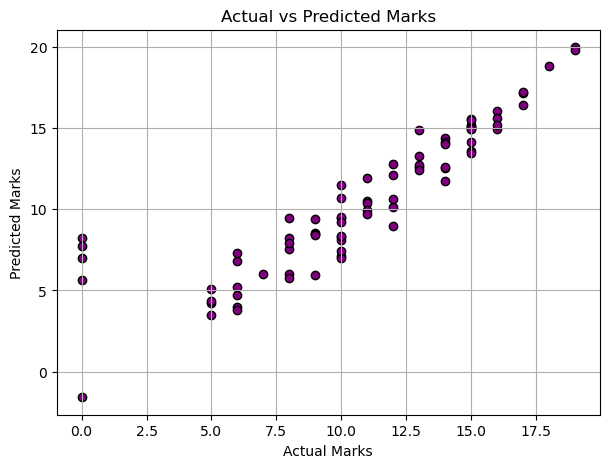

In [29]:
# Actual vs Predicted graph
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='purple', edgecolors='black')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.grid(True)
plt.show()

### The scatter plot compares actual and predicted marks. The points are relatively close, indicating that the model performs well in predicting student grades.